#дз 4

#Часть 1

**SPADes**

'#!/bin/sh

'#SBATCH --job-name=spades_raw

'#SBATCH --cpus-per-task=8

'#SBATCH --mem=32gb

'#SBATCH --time=06:00:00

'#SBATCH --partition=IXG6154-AI-common

'#SBATCH --output=/home/STUDY/FBMF/studfbmf02_19/seminars/sem11/logs/spades_raw.%j.log

python3 /home/STUDY/FBMF/bioinformatics/soft/SPAdes-4.2.0-Linux/bin/spades.py \
  --careful \
  -1 /home/STUDY/FBMF/studfbmf02_19/genome_de_novo/7_S4_L001_R1_001.fastq \
  -2 /home/STUDY/FBMF/studfbmf02_19/genome_de_novo/7_S4_L001_R2_001.fastq \
  -o /home/STUDY/FBMF/studfbmf02_19/seminars/sem11/genome_assembly_results/spades

**Velvet**

'#!/bin/sh

'#SBATCH --job-name=velvet_raw

'#SBATCH --cpus-per-task=4

'#SBATCH --mem=16gb

'#SBATCH --time=06:00:00

'#SBATCH --partition=IXG6154-AI-common

'#SBATCH --output=/home/STUDY/FBMF/studfbmf02_19/seminars/sem11/logs/velvet_raw.%j.log

for K in 21 31 41 51

do

  /home/STUDY/FBMF/bioinformatics/soft/velvet/velveth \
    /home/STUDY/FBMF/studfbmf02_19/seminars/sem11/genome_assembly_results/velvet/k${K} ${K} \
    -fastq -shortPaired \
    /home/STUDY/FBMF/studfbmf02_19/genome_de_novo/7_S4_L001_R1_001.fastq \
    /home/STUDY/FBMF/studfbmf02_19/genome_de_novo/7_S4_L001_R2_001.fastq

  /home/STUDY/FBMF/bioinformatics/soft/velvet/velvetg \
    /home/STUDY/FBMF/studfbmf02_19/seminars/sem11/genome_assembly_results/velvet/k${K} \
    -ins_length 300
    
done

**Результаты Velvet**

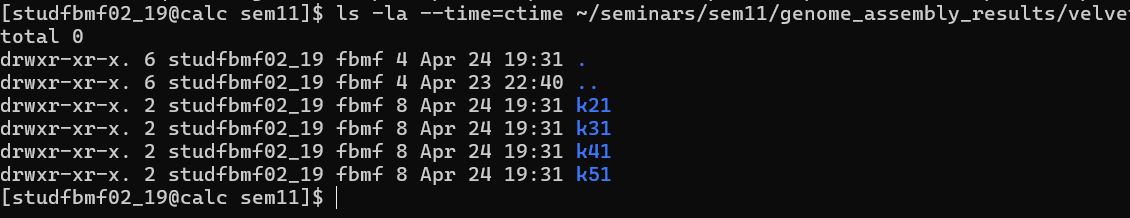

#Часть 2

QUAST

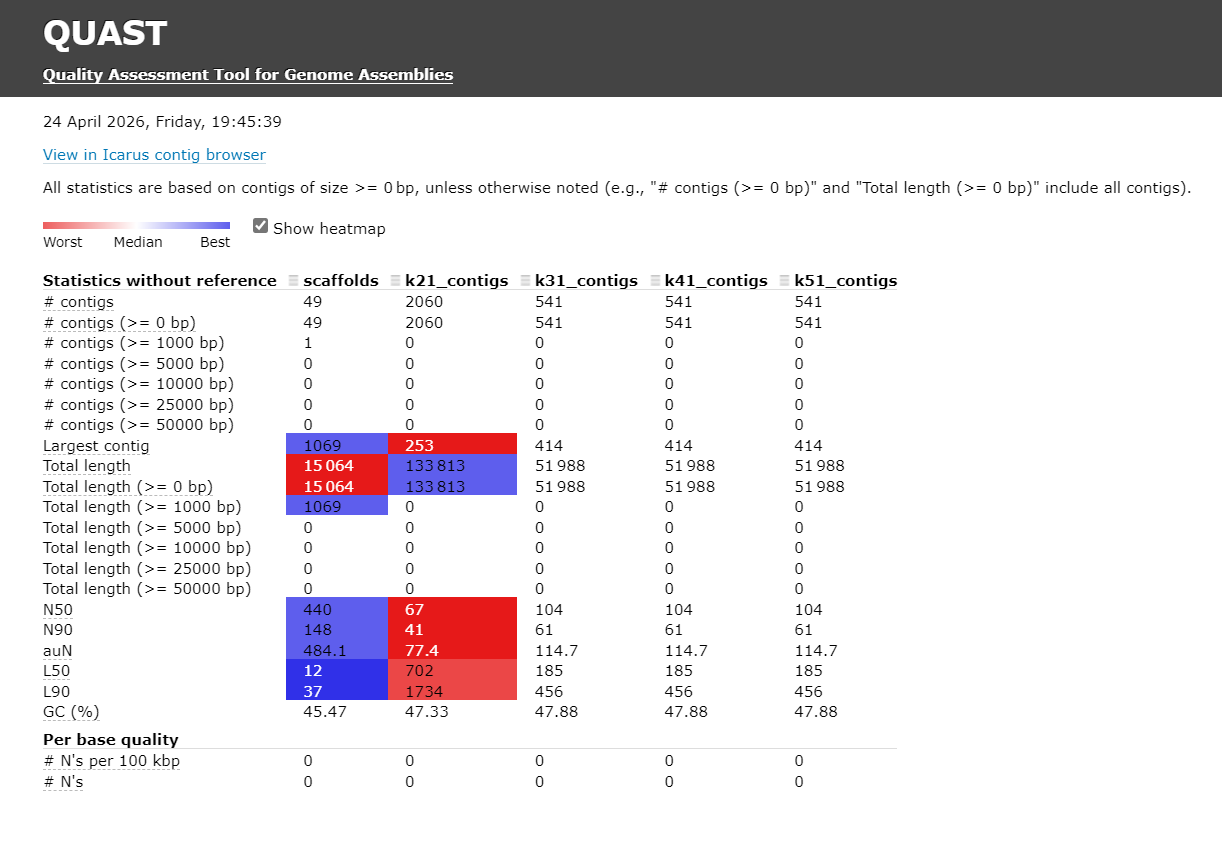

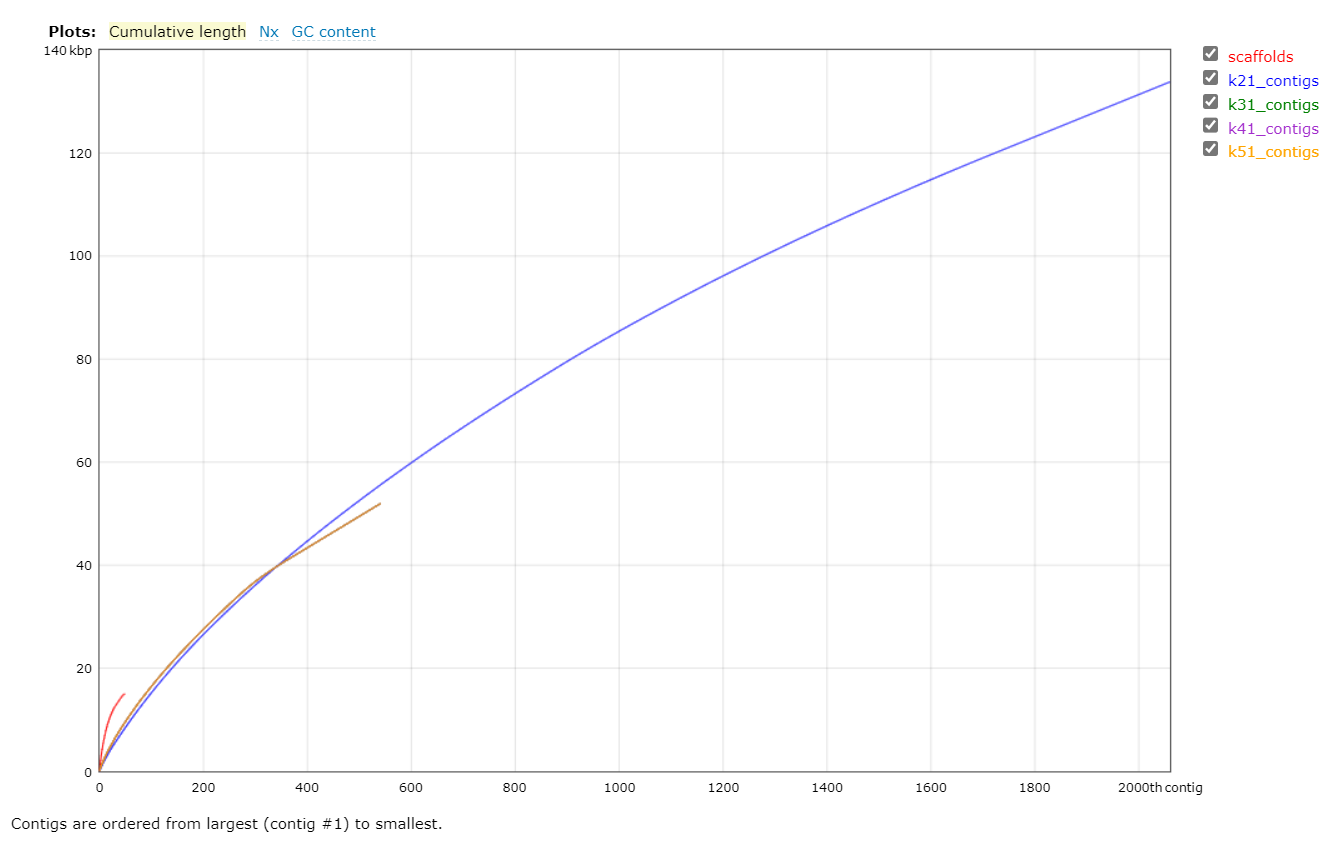

Отчет QUAST (report.html) был загружен в GitHub-репозиторий проекта:
https://github.com/AllaChekel/Bioinform_Alla_2026

**Вывод**

Согласно результатам QUAST, сборка, полученная с помощью SPAdes, является более качественной по сравнению с Velvet.

SPAdes показывает:

меньшее количество контигов (49), что говорит о более цельной сборке
более высокое значение N50 (440), что указывает на большую длину контигов
больший максимальный контиг (1069)/

Velvet:

при k=21 даёт сильно фрагментированную сборку (2060 контигов)
при k=31, 41 и 51 результаты совпадают (541 контиг, N50=104), но остаются хуже SPAdes.

Таким образом, SPAdes демонстрирует более качественную и стабильную сборку без необходимости подбора параметров, в то время как Velvet требует подбора k-mer и всё равно уступает по основным метрикам.Меньшее число контигов свидетельствует о более непрерывной и менее фрагментированной сборке.

#Часть 3

Для улучшения качества сборки была проведена предварительная обработка ридов (trimming), направленная на удаление низкокачественных участков последовательностей.

Низкокачественные базы и адаптеры могут приводить к ошибкам при сборке и увеличению числа коротких контигов. Поэтому их удаление должно улучшить непрерывность сборки.

**Скрипты**

trimming (fastp)
fastp \
  -i /home/STUDY/FBMF/studfbmf02_19/genome_de_novo/7_S4_L001_R1_001.fastq \
  -I /home/STUDY/FBMF/studfbmf02_19/genome_de_novo/7_S4_L001_R2_001.fastq \
  -o /home/STUDY/FBMF/studfbmf02_19/seminars/sem11/report_files/R1_paired.fastq \
  -O /home/STUDY/FBMF/studfbmf02_19/seminars/sem11/report_files/R2_paired.fastq \
  -w 4

SPAdes (trimmed)

python3 /home/STUDY/FBMF/bioinformatics/soft/SPAdes-4.2.0-Linux/bin/spades.py \
  --careful \
  -1 /home/STUDY/FBMF/studfbmf02_19/seminars/sem11/report_files/R1_paired.fastq \
  -2 /home/STUDY/FBMF/studfbmf02_19/seminars/sem11/report_files/R2_paired.fastq \
  -o /home/STUDY/FBMF/studfbmf02_19/seminars/sem11/genome_assembly_results/spades_trimmed

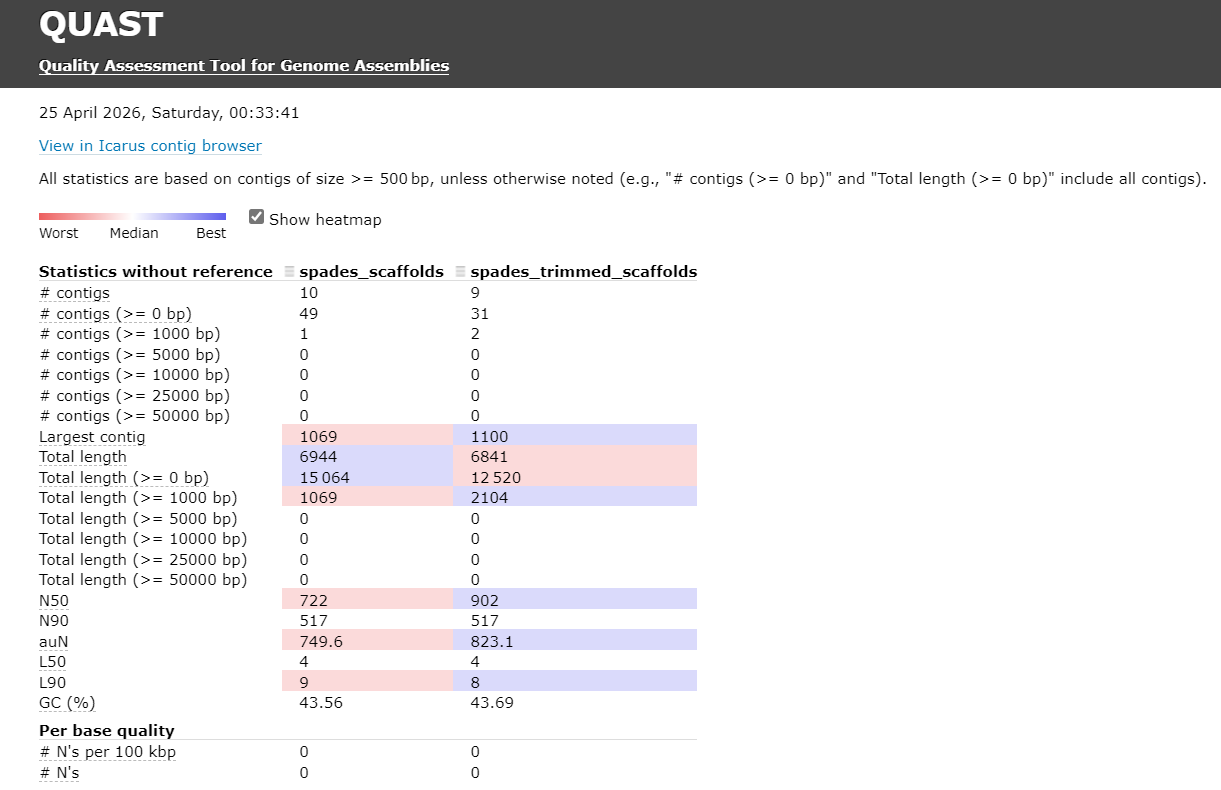

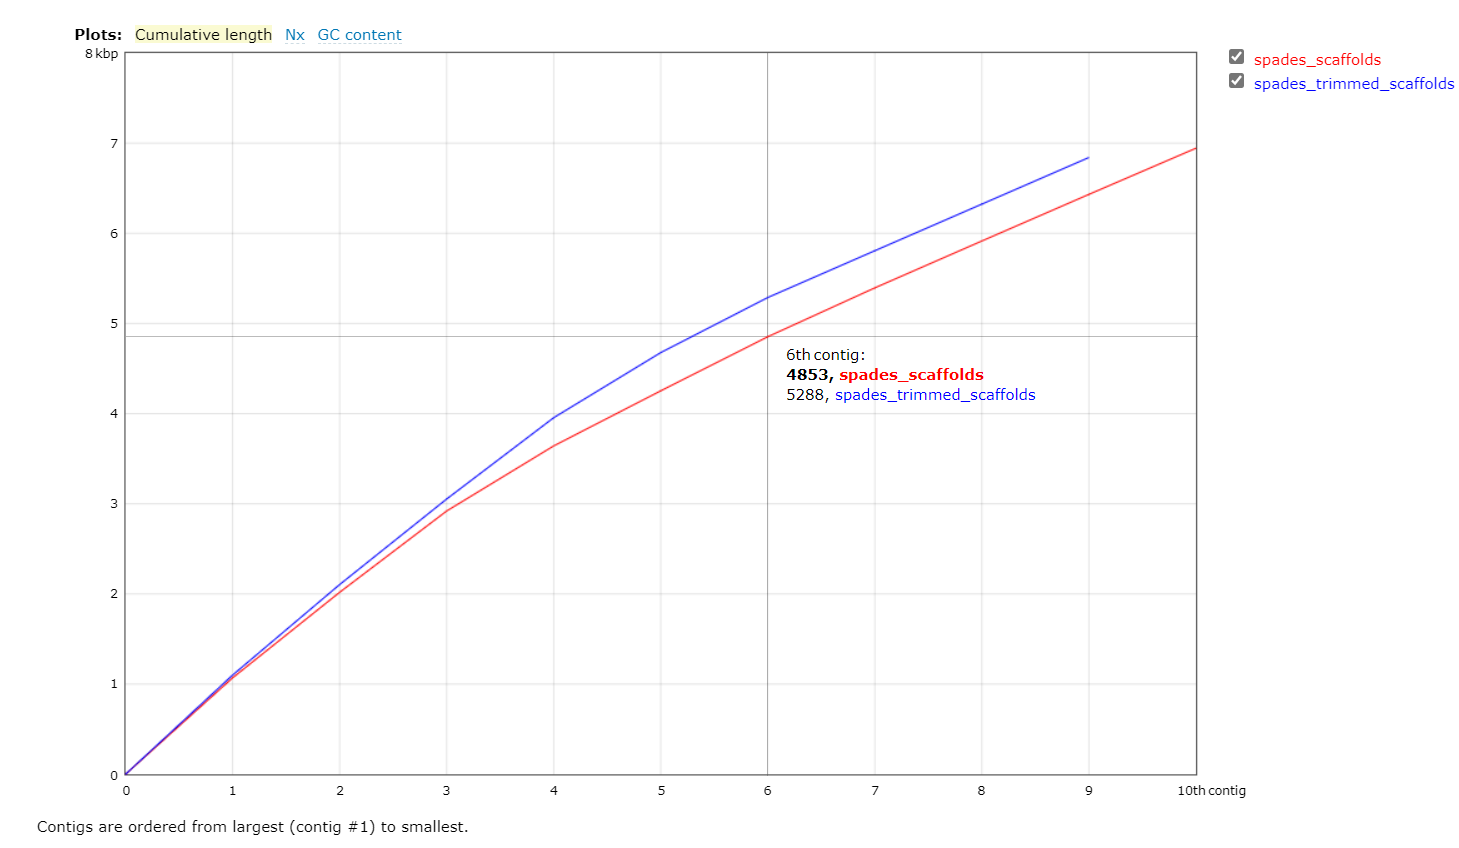

Сравнение сборок до и после обработки ридов показало улучшение качества сборки.

После trimming:

уменьшилось количество контигов (с 10 до 9), что говорит о снижении фрагментации,
увеличилась длина наибольшего контига (с 1069 до 1100),
значительно вырос показатель N50 (с 722 до 902), ччто свидетельствует о повышении непрерывности сборки и увеличении длины типичных контигов,
уменьшился показатель L90, что указывает на более компактную сборку.

Таким образом, обработка данных позволила получить более качественную и непрерывную сборку.

#Вывод
В ходе работы были выполнены сборки генома с использованием программ Velvet и SPAdes, а также проведена предварительная обработка ридов (trimming).

Сравнение показало, что SPAdes обеспечивает более качественную сборку по сравнению с Velvet, что выражается в меньшем числе контигов и более высоких значениях метрики N50.

Дополнительная фильтрация ридов позволила улучшить качество сборки: уменьшилось количество контигов, увеличилась длина наибольшего контига и существенно вырос показатель N50, что свидетельствует о повышении непрерывности сборки.

Таким образом, использование предварительной обработки данных и современных алгоритмов сборки позволяет значительно повысить качество получаемых результатов.